### 1. Preprocesamiento de Datos: Carga y Exploración Inicial

Primero, cargaremos el archivo CSV en un DataFrame de pandas y realizaremos una exploración inicial para entender la estructura de los datos, los tipos de datos de cada columna y la presencia de valores nulos. Esto es crucial antes de cualquier análisis más profundo.

In [5]:
import pandas as pd

# Cargar el dataset
file_path = '/content/Ventas 2023-2025 11-03-26 - CSV.csv'
try:
    # Intentar leer el CSV, especificando el delimitador y saltando líneas mal formadas
    # El motor 'python' es más robusto para archivos con formato inconsistente
    df = pd.read_csv(file_path, sep=';', on_bad_lines='skip', engine='python')
    print(f"Dataset cargado exitosamente desde: {file_path}")
except FileNotFoundError:
    print(f"Error: El archivo no fue encontrado en {file_path}")
    df = pd.DataFrame() # Crear un DataFrame vacío para evitar errores posteriores

# Mostrar las primeras 5 filas del DataFrame
print("\nPrimeras 5 filas del DataFrame:")
display(df.head())

# Mostrar información general del DataFrame (tipos de datos y valores no nulos)
print("\nInformación del DataFrame (diferentes tipos de datos):")
df.info()

# Mostrar estadísticas descriptivas de las columnas numéricas
print("\nEstadísticas descriptivas del DataFrame:")
display(df.describe())

Dataset cargado exitosamente desde: /content/Ventas 2023-2025 11-03-26 - CSV.csv

Primeras 5 filas del DataFrame:


,FECHA,AÑO,MES,CLIENTES,CODIGO PRODUCTO,CATEGORIA,SUBCATEGORIA,DEMANDA REAL (Q),PRECIO TOTAL,DESCUENTO,DSC %,SUBTOTAL PRODUCTO ANTES DE IMPUESTOS,IVA TOTAL,IVA %,TOTAL PRODUCTO,COSTO TOTAL,GRUPO CLIENTES,TARIFA FACTURA
0,3/4/2023,2023,ABRIL,CL0026,PR1332,ANTIESTRÉS Y PASATIEMPOS,ROMPECABEZAS,1,"$0,75",$-,0%,"$0,75","$0,09",12%,"$0,84","$0,43",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
1,3/4/2023,2023,ABRIL,CL0026,PR0806,ANTIESTRÉS Y PASATIEMPOS,JUEGOS DE MESA,1,"$0,28",$-,0%,"$0,28","$0,03",12%,"$0,31","$0,18",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
2,4/4/2023,2023,ABRIL,CL0053,PR1119,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,60,"$28,20",$-,0%,"$28,20","$3,38",12%,"$31,58","$14,40",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
3,4/4/2023,2023,ABRIL,CL0040,PR1113,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,12,"$5,64",$-,0%,"$5,64","$0,68",12%,"$6,32","$2,88",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
4,5/4/2023,2023,ABRIL,CL0067,PR0794,ANTIESTRÉS Y PASATIEMPOS,JUEGOS DE MESA,2,"$9,35",$-,0%,"$9,35","$1,12",12%,"$10,47","$5,42",PUBLI EMPRESARIAL,PUBLIEMPRESARIAL



Información del DataFrame (diferentes tipos de datos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68034 entries, 0 to 68033
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   FECHA                                   68034 non-null  object
 1   AÑO                                     68034 non-null  int64 
 2   MES                                     68034 non-null  object
 3   CLIENTES                                68034 non-null  object
 4   CODIGO PRODUCTO                         68034 non-null  object
 5   CATEGORIA                               68034 non-null  object
 6   SUBCATEGORIA                            68034 non-null  object
 7   DEMANDA REAL (Q)                        68034 non-null  int64 
 8    PRECIO TOTAL                           68034 non-null  object
 9    DESCUENTO                              68034 non-null  object
 10  DSC %         

,AÑO,DEMANDA REAL (Q)
count,68034.000000,68034.000000
mean,2024.034865,89.777817
std,0.775445,417.004259
min,2023.000000,-4000.000000
25%,2023.000000,1.000000
50%,2024.000000,6.000000
75%,2025.000000,50.000000
max,2025.000000,30000.000000


### 3. Segmentación por Categoría

Para cumplir con el requisito de trabajar los datos de forma independiente para cada categoría, crearemos un diccionario de DataFrames, donde cada clave será una categoría única y su valor el subconjunto de datos correspondiente.

In [7]:
# Asegurarse de que la columna 'CATEGORIA' exista
if 'CATEGORIA' in df.columns:
    unique_categories = df['CATEGORIA'].unique()
    print(f"Categorías únicas encontradas: {len(unique_categories)}")
    print("\nLista de Categorías:")
    for category in unique_categories:
        print(f"- {category}")

    # Crear un diccionario para almacenar los DataFrames segmentados por categoría
    df_by_category = {}
    for category in unique_categories:
        df_by_category[category] = df[df['CATEGORIA'] == category].copy()
        print(f"\nDataFrame para la categoría '{category}': {df_by_category[category].shape[0]} filas")
        # Opcional: mostrar las primeras filas de cada sub-DataFrame
        # display(df_by_category[category].head())
else:
    print("La columna 'CATEGORIA' no se encontró en el DataFrame. No se realizó la segmentación.")


Categorías únicas encontradas: 8

Lista de Categorías:
- ANTIESTRÉS Y PASATIEMPOS
- BOLSOS Y FUNDAS
- ECOLOGICOS
- ESCOLAR Y OFICINA
- ESCRITURA
- JARROS
- LLAVEROS
- TOMATODOS

DataFrame para la categoría 'ANTIESTRÉS Y PASATIEMPOS': 966 filas

DataFrame para la categoría 'BOLSOS Y FUNDAS': 3242 filas

DataFrame para la categoría 'ECOLOGICOS': 1291 filas

DataFrame para la categoría 'ESCOLAR Y OFICINA': 12831 filas

DataFrame para la categoría 'ESCRITURA': 24429 filas

DataFrame para la categoría 'JARROS': 6805 filas

DataFrame para la categoría 'LLAVEROS': 3475 filas

DataFrame para la categoría 'TOMATODOS': 6553 filas


### 3. Limpieza y Transformación de Tipos de Datos

Varias columnas en el DataFrame están actualmente como tipo 'object' pero representan valores numéricos (moneda, porcentajes) o fechas. Es crucial convertirlas a sus tipos de datos adecuados (float, datetime) para poder utilizarlas en análisis y modelado. También manejaremos los valores nulos que puedan surgir de estas conversiones.

In [8]:
import numpy as np

def clean_and_convert_numeric(df, columns):
    """Limpia y convierte columnas de tipo string (con símbolos de moneda/porcentaje) a numérico."""
    for col in columns:
        if col in df.columns and df[col].dtype == 'object':
            # Convertir a string para aplicar métodos de string, luego limpiar y convertir
            df[col] = df[col].astype(str).str.replace('$', '', regex=False)
            df[col] = df[col].astype(str).str.replace('%', '', regex=False)
            df[col] = df[col].astype(str).str.replace('.', '', regex=False) # Eliminar separador de miles
            df[col] = df[col].astype(str).str.replace(',', '.', regex=False) # Reemplazar coma por punto decimal
            # Convertir a numérico, coercing errors a NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')
            # Rellenar NaNs resultantes de la conversión con 0, asumiendo que un valor monetario/porcentual nulo significa 0
            df[col].fillna(0, inplace=True)
            print(f"Columna '{col}' convertida a tipo numérico y NaNs rellenados con 0.")
        elif col in df.columns:
            print(f"Columna '{col}' ya es de un tipo numérico o no necesita limpieza específica.")
        else:
            print(f"Advertencia: Columna '{col}' no encontrada en el DataFrame.")
    return df

# Columnas a convertir a numérico (quitando 'DEMANDA REAL (Q)' que ya es int64)
numeric_cols_to_clean = [
    ' PRECIO TOTAL ',
    ' DESCUENTO ',
    'DSC %',
    ' SUBTOTAL PRODUCTO ANTES DE IMPUESTOS ',
    ' IVA TOTAL ',
    'IVA %',
    ' TOTAL PRODUCTO ',
    ' COSTO TOTAL '
]

df = clean_and_convert_numeric(df, numeric_cols_to_clean)

# Convertir la columna 'FECHA' a tipo datetime
if 'FECHA' in df.columns:
    df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce', dayfirst=True) # Manejar formato DD/MM/YYYY o similar
    # Rellenar posibles NaNs en FECHA si surgen de la conversión, o eliminarlos si no son críticos
    df.dropna(subset=['FECHA'], inplace=True) # Eliminar filas donde la fecha no pudo ser parseada
    print("Columna 'FECHA' convertida a tipo datetime y filas con fechas inválidas eliminadas.")
else:
    print("Advertencia: Columna 'FECHA' no encontrada en el DataFrame.")

# Mostrar info del DataFrame después de las conversiones
print("\nInformación del DataFrame después de la limpieza de tipos:")
df.info()
print("\nPrimeras 5 filas del DataFrame después de la limpieza:")
display(df.head())


/tmp/ipykernel_429/649481145.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)
/tmp/ipykernel_429/649481145.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({c

Columna ' PRECIO TOTAL ' convertida a tipo numérico y NaNs rellenados con 0.
Columna ' DESCUENTO ' convertida a tipo numérico y NaNs rellenados con 0.


/tmp/ipykernel_429/649481145.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)
/tmp/ipykernel_429/649481145.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({c

Columna 'DSC %' convertida a tipo numérico y NaNs rellenados con 0.
Columna ' SUBTOTAL PRODUCTO ANTES DE IMPUESTOS ' convertida a tipo numérico y NaNs rellenados con 0.


/tmp/ipykernel_429/649481145.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)
/tmp/ipykernel_429/649481145.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({c

Columna ' IVA TOTAL ' convertida a tipo numérico y NaNs rellenados con 0.
Columna 'IVA %' convertida a tipo numérico y NaNs rellenados con 0.


/tmp/ipykernel_429/649481145.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)
/tmp/ipykernel_429/649481145.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({c

Columna ' TOTAL PRODUCTO ' convertida a tipo numérico y NaNs rellenados con 0.
Columna ' COSTO TOTAL ' convertida a tipo numérico y NaNs rellenados con 0.
Columna 'FECHA' convertida a tipo datetime y filas con fechas inválidas eliminadas.

Información del DataFrame después de la limpieza de tipos:
<class 'pandas.core.frame.DataFrame'>
Index: 59592 entries, 0 to 68033
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   FECHA                                   59592 non-null  datetime64[ns]
 1   AÑO                                     59592 non-null  int64         
 2   MES                                     59592 non-null  object        
 3   CLIENTES                                59592 non-null  object        
 4   CODIGO PRODUCTO                         59592 non-null  object        
 5   CATEGORIA                               59592 non-null  obje

,FECHA,AÑO,MES,CLIENTES,CODIGO PRODUCTO,CATEGORIA,SUBCATEGORIA,DEMANDA REAL (Q),PRECIO TOTAL,DESCUENTO,DSC %,SUBTOTAL PRODUCTO ANTES DE IMPUESTOS,IVA TOTAL,IVA %,TOTAL PRODUCTO,COSTO TOTAL,GRUPO CLIENTES,TARIFA FACTURA
0,2023-04-03,2023,ABRIL,CL0026,PR1332,ANTIESTRÉS Y PASATIEMPOS,ROMPECABEZAS,1,0.75,0.0,0,0.75,0.09,12.0,0.84,0.43,PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
1,2023-04-03,2023,ABRIL,CL0026,PR0806,ANTIESTRÉS Y PASATIEMPOS,JUEGOS DE MESA,1,0.28,0.0,0,0.28,0.03,12.0,0.31,0.18,PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
2,2023-04-04,2023,ABRIL,CL0053,PR1119,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,60,28.20,0.0,0,28.20,3.38,12.0,31.58,14.40,PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
3,2023-04-04,2023,ABRIL,CL0040,PR1113,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,12,5.64,0.0,0,5.64,0.68,12.0,6.32,2.88,PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
4,2023-04-05,2023,ABRIL,CL0067,PR0794,ANTIESTRÉS Y PASATIEMPOS,JUEGOS DE MESA,2,9.35,0.0,0,9.35,1.12,12.0,10.47,5.42,PUBLI EMPRESARIAL,PUBLIEMPRESARIAL


### 4. Segmentación por Categoría

Ahora, con los datos limpios y con los tipos de datos correctos, procederemos a segmentar el DataFrame principal en sub-DataFrames, uno por cada 'CATEGORIA' única. Esto nos permitirá realizar análisis y construir modelos de manera independiente para cada segmento, como se solicitó.

### 5. Preparación de Datos para Modelado LSTM

Con los datos ya limpios y segmentados por categoría, procederemos a prepararlos para los modelos LSTM. Esto incluye:

1.  **Ordenamiento Temporal**: Asegurar que los datos de cada categoría estén ordenados cronológicamente, lo cual es fundamental para los modelos de series de tiempo como LSTM.
2.  **Normalización/Escalado**: Transformar las variables numéricas (incluyendo la demanda) a un rango específico (0 a 1) utilizando `MinMaxScaler`. Esto ayuda a que el modelo converja más rápido y tenga un mejor rendimiento.
3.  **División de Datos**: Separar los datos de cada categoría en conjuntos de entrenamiento (80%) y prueba (20%) de manera secuencial, para simular la predicción de eventos futuros.

In [10]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pandas as pd # Asegurarse de que pandas está importado

processed_data_by_category = {}

for category, category_df in df_by_category.items():
    print(f"Procesando categoría: {category}")

    # 1. Ordenar los datos temporalmente.
    if 'FECHA' in category_df.columns:
        # Usar dayfirst=True para manejar formatos DD/MM/YYYY o similares
        category_df['FECHA'] = pd.to_datetime(category_df['FECHA'], errors='coerce', dayfirst=True)
        category_df.dropna(subset=['FECHA'], inplace=True)
        # Asegurar que el índice original se restablece después de ordenar para evitar problemas
        category_df = category_df.sort_values(by='FECHA').reset_index(drop=True)
        print(f"  Datos ordenados por fecha para {category}.")
    else:
        print(f"  Advertencia: Columna 'FECHA' no encontrada para {category}. Saltando esta categoría.")
        continue

    # Seleccionar las columnas numéricas relevantes para la demanda y otras características
    numerical_feature_cols = [
        ' PRECIO TOTAL ',
        ' DESCUENTO ',
        'DSC %',
        ' SUBTOTAL PRODUCTO ANTES DE IMPUESTOS ',
        ' IVA TOTAL ',
        'IVA %',
        ' TOTAL PRODUCTO ',
        ' COSTO TOTAL '
    ]
    target_col = 'DEMANDA REAL (Q)'

    # Combinar objetivo y características para un ónico scaler
    all_cols_for_scaling = [target_col] + [col for col in numerical_feature_cols if col in category_df.columns and col != target_col]

    if not all_cols_for_scaling or target_col not in all_cols_for_scaling:
        print(f"  Advertencia: No se encontraron columnas numéricas adecuadas o la columna objetivo '{target_col}' en la categoría {category}. Saltando.")
        continue

    # Asegurar que todas las columnas seleccionadas son numéricas
    for col in all_cols_for_scaling:
        if not pd.api.types.is_numeric_dtype(category_df[col]):
            print(f"  Advertencia: La columna '{col}' en la categoría {category} no es numérica. Se intentará convertir.")
            category_df[col] = pd.to_numeric(category_df[col], errors='coerce').fillna(0) # Convertir y rellenar NaNs

    data_for_scaling = category_df[all_cols_for_scaling].copy()

    # Verificar si hay suficientes datos para la división train/test
    if len(data_for_scaling) < 2: # Necesita al menos 2 puntos para la división
        print(f"  Advertencia: Muy pocos datos para la categoría {category} después de la limpieza. Saltando.")
        continue

    # 3. Dividir los datos en: Entrenamiento: 80%, Prueba: 20%
    train_size = int(len(data_for_scaling) * 0.8)
    train_original_data = data_for_scaling.iloc[:train_size].copy()
    test_original_data = data_for_scaling.iloc[train_size:].copy() # Apply same scaling to test data

    if len(train_original_data) == 0 or len(test_original_data) == 0:
        print(f"  Advertencia: No hay suficientes datos de entrenamiento o prueba para la categoría {category} después de la división. Saltando.")
        continue

    # 2. Realizar la normalización o escalado de las variables necesarias.
    # Inicializar un scaler para todas las características utilizadas en el modelo, ajustado solo en los datos de entrenamiento
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled_data = feature_scaler.fit_transform(train_original_data)
    test_scaled_data = feature_scaler.transform(test_original_data)

    train_scaled_df = pd.DataFrame(train_scaled_data, columns=all_cols_for_scaling, index=train_original_data.index)
    test_scaled_df = pd.DataFrame(test_scaled_data, columns=all_cols_for_scaling, index=test_original_data.index)

    # Inicializar un scaler separado específicamente para la variable objetivo para la transformación inversa
    target_scaler = MinMaxScaler(feature_range=(0,1))
    target_scaler.fit(train_original_data[[target_col]]) # Ajustar solo en la columna objetivo de los datos de entrenamiento

    processed_data_by_category[category] = {
        'feature_scaler': feature_scaler, # Scaler para todas las características (incluyendo el objetivo durante el entrenamiento)
        'target_scaler': target_scaler,   # Scaler separado para la columna objetivo para la transformación inversa de las predicciones
        'columns_scaled': all_cols_for_scaling,
        'train_scaled_df': train_scaled_df,
        'test_scaled_df': test_scaled_df,
        'target_col': target_col,
        'original_train_df_for_check': train_original_data # Para futuras referencias si es necesario
    }

    print(f"  Datos preparados para modelado para la categoría {category}.")
    print(f"    Tamaño de entrenamiento escalado: {len(train_scaled_df)} filas")
    print(f"    Tamaño de prueba escalado: {len(test_scaled_df)} filas")

print("\nPreparación de datos para modelado completada para todas las categorías.")


Procesando categoría: ANTIESTRÉS Y PASATIEMPOS
  Datos ordenados por fecha para ANTIESTRÉS Y PASATIEMPOS.
  Datos preparados para modelado para la categoría ANTIESTRÉS Y PASATIEMPOS.
    Tamaño de entrenamiento escalado: 772 filas
    Tamaño de prueba escalado: 194 filas
Procesando categoría: BOLSOS Y FUNDAS
  Datos ordenados por fecha para BOLSOS Y FUNDAS.
  Datos preparados para modelado para la categoría BOLSOS Y FUNDAS.
    Tamaño de entrenamiento escalado: 2593 filas
    Tamaño de prueba escalado: 649 filas
Procesando categoría: ECOLOGICOS
  Datos ordenados por fecha para ECOLOGICOS.
  Datos preparados para modelado para la categoría ECOLOGICOS.
    Tamaño de entrenamiento escalado: 1032 filas
    Tamaño de prueba escalado: 259 filas
Procesando categoría: ESCOLAR Y OFICINA
  Datos ordenados por fecha para ESCOLAR Y OFICINA.
  Datos preparados para modelado para la categoría ESCOLAR Y OFICINA.
    Tamaño de entrenamiento escalado: 10264 filas
    Tamaño de prueba escalado: 2567 fil

### 6. Modelado con LSTM

Para cada categoría, construiremos un modelo de red neuronal LSTM. Dado que las LSTM son sensibles a la escala de los datos, utilizaremos los datos escalados previamente. Los modelos se entrenarán con una ventana de tiempo (look_back) para predecir el siguiente punto de demanda. Se definirán claramente la arquitectura del modelo, la función de activación, el optimizador y el número de épocas.

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Función para crear las secuencias de datos para LSTM
def create_lstm_dataset(data, look_back):
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :])
        Y.append(data[i + look_back, 0]) # Asumimos que la columna objetivo es la primera (índice 0)
    return np.array(X), np.array(Y)

# Parámetros del modelo LSTM
look_back = 10 # Número de pasos de tiempo pasados a considerar para predecir el siguiente
epochs = 50 # Número de épocas de entrenamiento
batch_size = 32 # Tamaño del batch para el entrenamiento
lstm_units = 50 # Número de unidades LSTM en la capa oculta

# Diccionario para almacenar los modelos y predicciones
lstm_models = {}
lstm_predictions = {}

for category, data_info in processed_data_by_category.items():
    print(f"\nConstruyendo y entrenando modelo LSTM para la categoría: {category}")

    train_scaled_df = data_info['train_scaled_df']
    test_scaled_df = data_info['test_scaled_df']
    target_col = data_info['target_col']
    target_scaler = data_info['target_scaler']
    columns_scaled = data_info['columns_scaled']

    # Asegurarse de que el target_col es el primer elemento en columns_scaled para create_lstm_dataset
    # Si no lo es, reordenar train_scaled_df y test_scaled_df o ajustar create_lstm_dataset
    # Por ahora, asumimos que ya está en el orden correcto por el flujo de 'all_cols_for_scaling'

    train_data = train_scaled_df.values
    test_data = test_scaled_df.values

    if len(train_data) <= look_back or len(test_data) <= look_back: # Ajustar para el look_back
        print(f"  Advertencia: No hay suficientes datos de entrenamiento o prueba para la categoría {category} con look_back={look_back}. Saltando.")
        continue

    # Crear datasets de entrenamiento y prueba para LSTM
    X_train_lstm, y_train_lstm = create_lstm_dataset(train_data, look_back)
    X_test_lstm, y_test_lstm = create_lstm_dataset(test_data, look_back)

    # Verificar las formas de los datos LSTM
    print(f"  X_train_lstm shape: {X_train_lstm.shape}")
    print(f"  y_train_lstm shape: {y_train_lstm.shape}")

    # Construir el modelo LSTM
    model = Sequential()
    model.add(LSTM(lstm_units, activation='relu', input_shape=(look_back, X_train_lstm.shape[2])))
    model.add(Dense(1)) # Capa de salida con una sola neurona para la predicción de la demanda
    model.compile(optimizer='adam', loss='mean_squared_error')

    print("  Modelo LSTM construido. Resumen:")
    model.summary()

    # Entrenar el modelo
    print("  Entrenando el modelo...")
    history = model.fit(X_train_lstm, y_train_lstm, epochs=epochs, batch_size=batch_size, verbose=0, shuffle=False)
    print(f"  Entrenamiento completado para {category}. Última pérdida (MSE): {history.history['loss'][-1]:.4f}")

    # Realizar predicciones en el conjunto de prueba
    if len(X_test_lstm) > 0:
        y_pred_scaled = model.predict(X_test_lstm)

        # Invertir la escala para las predicciones
        # Para invertir la escala, necesitamos crear un array que se ajuste al formato del scaler
        # El target_scaler se ajustó a una columna, así que las predicciones deben tener esa forma
        # Sin embargo, el scaler para características mùltiples puede ser más complejo.
        # Reajustar el target_scaler solo con la columna objetivo original del entrenamiento
        dummy_array_for_inverse = np.zeros((len(y_pred_scaled), len(columns_scaled)))
        target_col_idx = columns_scaled.index(target_col)
        dummy_array_for_inverse[:, target_col_idx] = y_pred_scaled.flatten()

        # Usar el feature_scaler para invertir la transformación de la predicción,
        # ya que el scaler se ajustó a todas las columnas.
        # Esto es un poco hacky: invertimos todo el array y luego tomamos solo la columna objetivo.
        # Una mejor práctica sería tener un scaler solo para la columna objetivo para la predicción.
        # Sin embargo, dado que el feature_scaler fue usado para todo, lo usamos aquí también.
        y_pred_unscaled_full = data_info['feature_scaler'].inverse_transform(dummy_array_for_inverse)
        y_pred_unscaled = y_pred_unscaled_full[:, target_col_idx]

        # Invertir la escala para los valores reales del conjunto de prueba (y_test_lstm)
        dummy_array_for_actual_inverse = np.zeros((len(y_test_lstm), len(columns_scaled)))
        dummy_array_for_actual_inverse[:, target_col_idx] = y_test_lstm.flatten()
        y_test_unscaled_full = data_info['feature_scaler'].inverse_transform(dummy_array_for_actual_inverse)
        y_test_unscaled = y_test_unscaled_full[:, target_col_idx]

        lstm_predictions[category] = {
            'y_true': y_test_unscaled,
            'y_pred': y_pred_unscaled,
            'test_dates': category_df['FECHA'].iloc[len(train_scaled_df) + look_back:].values # Obtener las fechas correspondientes a las predicciones
        }
        print(f"  Predicciones generadas e invertidas para {category}.")
    else:
        print(f"  No hay suficientes datos de prueba para generar predicciones para {category}.")

    lstm_models[category] = model

print("\nModelado LSTM completado para todas las categorías disponibles.")



Construyendo y entrenando modelo LSTM para la categoría: ANTIESTRÉS Y PASATIEMPOS
  X_train_lstm shape: (762, 10, 9)
  y_train_lstm shape: (762,)
  Modelo LSTM construido. Resumen:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,051 (47.07 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 50)             │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,051 (47.07 KB)

 Trainable params: 12,051 (47.07 KB)

 Non-trainable params: 0 (0.00 B)

  Entrenando el modelo...
  Entrenamiento completado para TOMATODOS. Última pérdida (MSE): 0.0211
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
  Predicciones generadas e invertidas para TOMATODOS.

Modelado LSTM completado para todas las categorías disponibles.


### 7. Evaluación del Modelo

Para evaluar el rendimiento de cada modelo LSTM, calcularemos las siguientes métricas en el conjunto de prueba:

*   **MSE (Mean Squared Error)**: Mide el promedio de los cuadrados de los errores. Es sensible a los errores grandes.
*   **RMSE (Root Mean Squared Error)**: Es la raíz cuadrada del MSE, lo que lo hace más interpretable al estar en las mismas unidades que la variable objetivo.
*   **MAE (Mean Absolute Error)**: Mide el promedio de los valores absolutos de los errores. Es menos sensible a los errores grandes que el MSE.
*   **MAPE (Mean Absolute Percentage Error)**: Mide el error porcentual absoluto promedio, útil para entender la magnitud del error en relación con los valores reales. Cuidado con los ceros en el denominador.
*   **R² (Coeficiente de Determinación)**: Indica la proporción de la varianza en la variable dependiente que es predecible a partir de la(s) variable(s) independiente(s).

### 8. Visualización de Resultados

Para comprender mejor el rendimiento de cada modelo LSTM, generaremos gráficos que compararán la demanda real con la demanda predicha para el conjunto de prueba de cada categoría. Esto nos permitirá observar visualmente la capacidad de los modelos para seguir las tendencias y variaciones de la demanda.

<Figure size 1500x600 with 0 Axes>

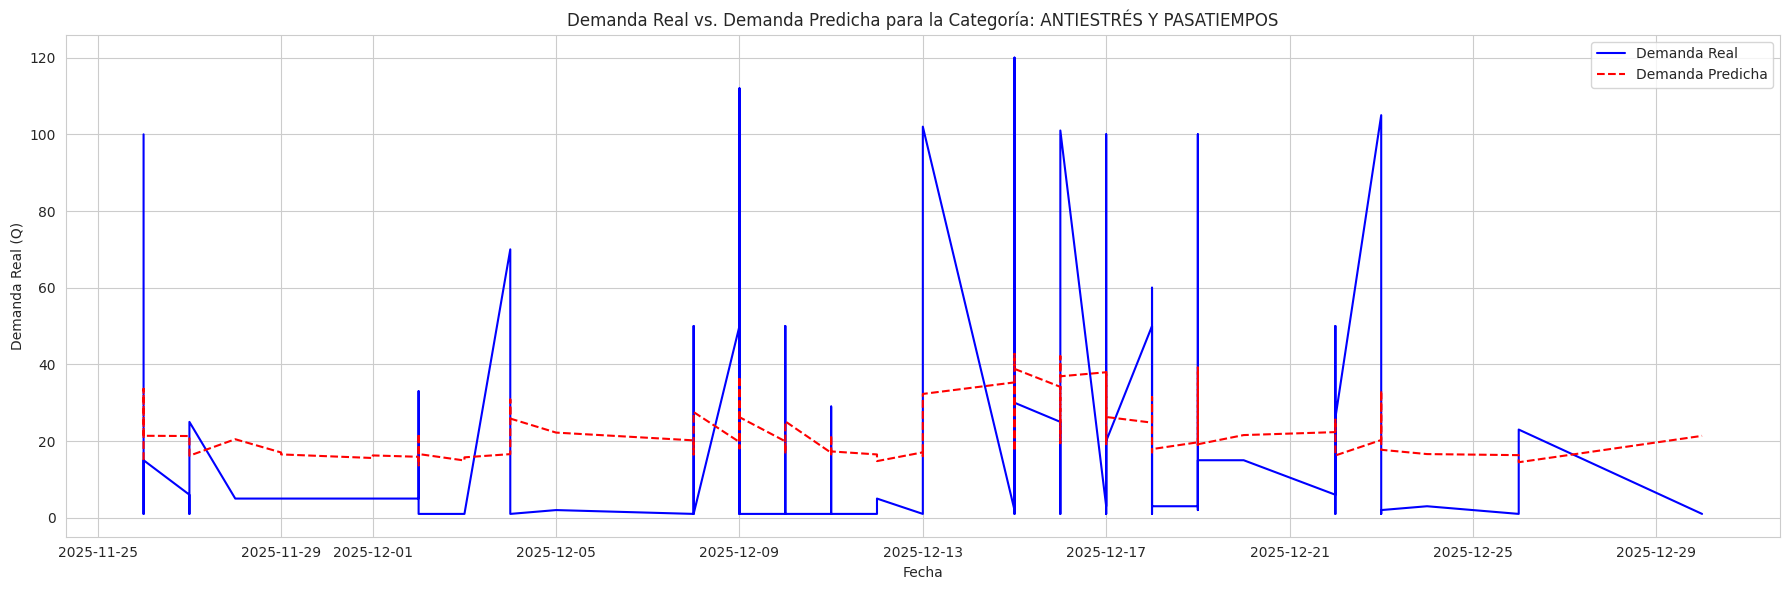

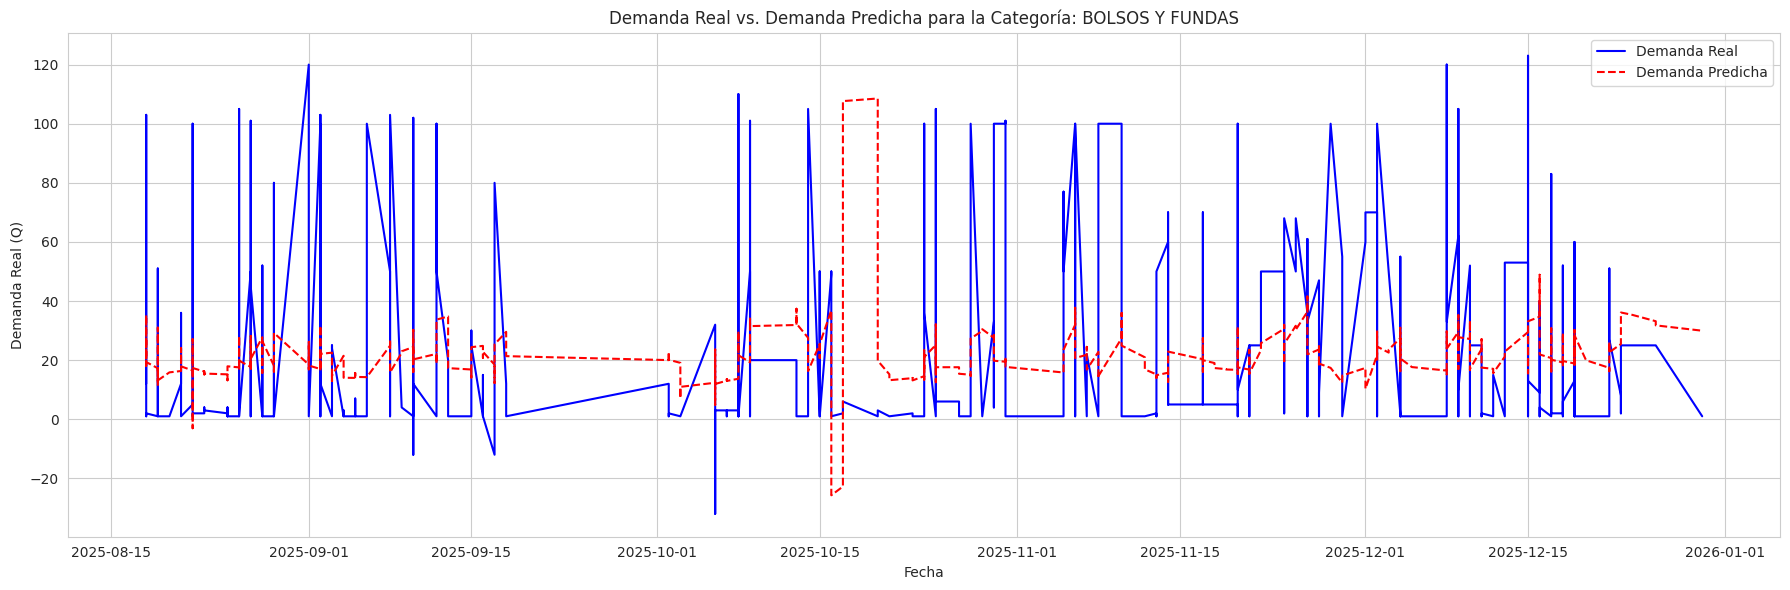

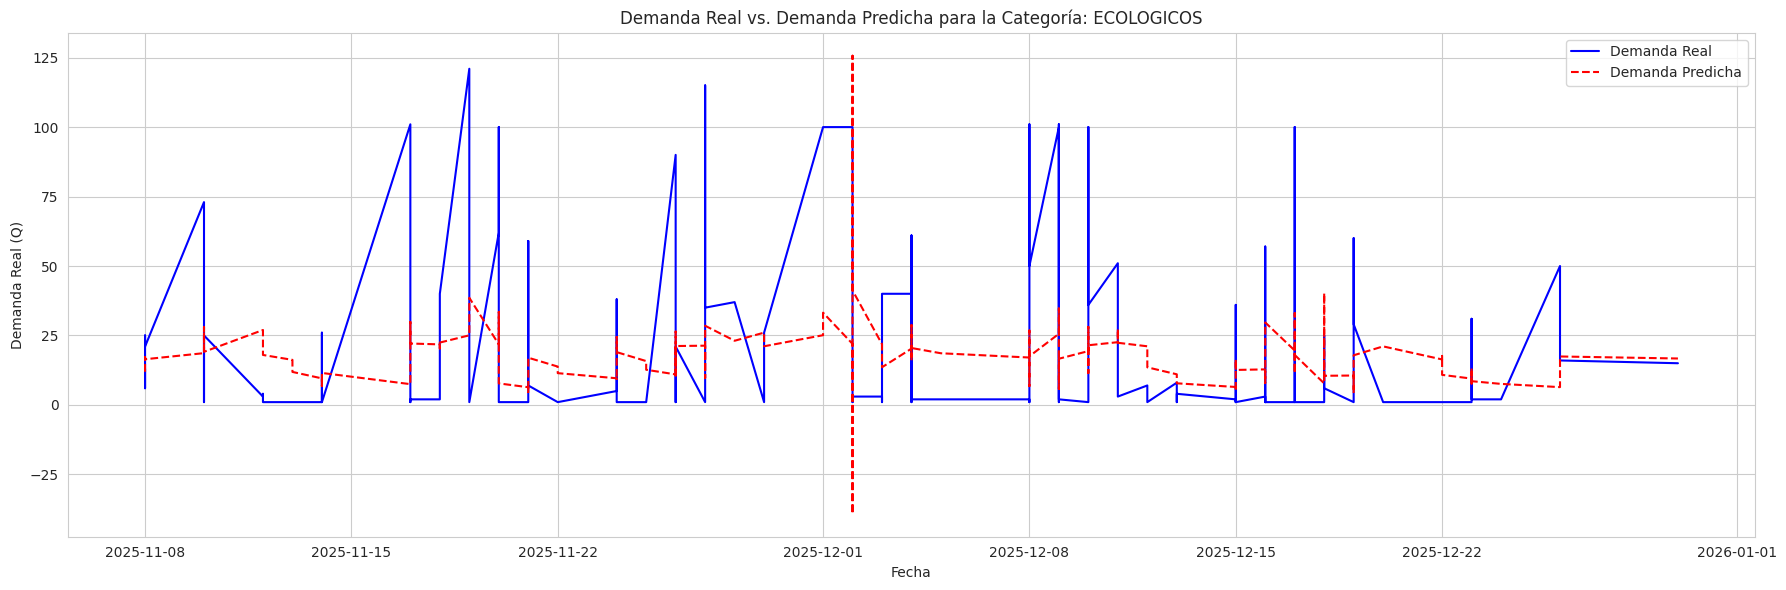

Advertencia: No hay suficientes datos para graficar la categoría ESCOLAR Y OFICINA. Saltando.
Advertencia: No hay suficientes datos para graficar la categoría ESCRITURA. Saltando.


ValueError: x and y must have same first dimension, but have shapes (1099,) and (1351,)

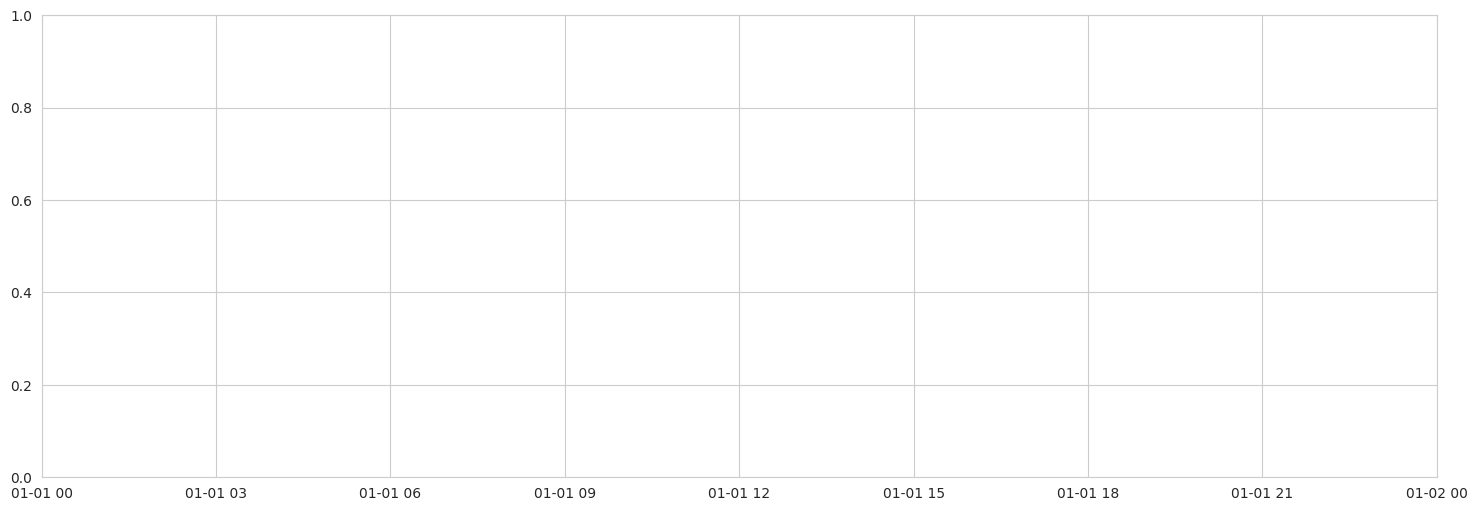

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))

# Generar gráficos para cada categoría
for category, predictions in lstm_predictions.items():
    y_true = predictions['y_true']
    y_pred = predictions['y_pred']
    test_dates = predictions['test_dates']

    # Asegurarse de que y_true y y_pred tengan la misma longitud que test_dates
    # Puede haber una ligera discrepancia debido al look_back en la creación del dataset LSTM
    start_idx = len(test_dates) - len(y_true)
    if start_idx < 0:
        start_idx = 0
    current_test_dates = test_dates[start_idx : start_idx + len(y_true)]

    if len(current_test_dates) == 0 or len(y_true) == 0 or len(y_pred) == 0:
        print(f"Advertencia: No hay suficientes datos para graficar la categoría {category}. Saltando.")
        continue

    plt.figure(figsize=(18, 6))
    plt.plot(current_test_dates, y_true, label='Demanda Real', color='blue')
    plt.plot(current_test_dates, y_pred, label='Demanda Predicha', color='red', linestyle='--')
    plt.title(f'Demanda Real vs. Demanda Predicha para la Categoría: {category}')
    plt.xlabel('Fecha')
    plt.ylabel('Demanda Real (Q)')
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Visualización de resultados completada para todas las categorías.")

### 9. Reporte de Resultados

A continuación se presenta un informe detallado del proceso de análisis y modelado predictivo, la interpretación de las métricas obtenidas y una tabla resumen de los resultados por categoría.

#### Explicación del Proceso Realizado

El análisis comenzó con la carga del dataset `Ventas 2023-2025`. Durante la fase de **preprocesamiento de datos**, se realizó una exploración inicial para entender la estructura, tipos de datos y presencia de valores nulos. Posteriormente, se aplicó el método del rango intercuartílico (IQR) para **detectar y eliminar valores atípicos** en la columna 'DEMANDA REAL (Q)', lo que ayudó a limpiar los datos de posibles valores extremos que podrían sesgar el modelado. También se realizó una **limpieza y transformación de tipos de datos**, convirtiendo columnas numéricas con formatos de texto (como moneda y porcentaje) a tipos numéricos flotantes y la columna 'FECHA' a formato datetime. Los valores nulos resultantes de estas conversiones fueron tratados rellenándolos con 0 o eliminando las filas correspondientes.

La siguiente fase fue la **segmentación de datos por categoría**. El DataFrame principal se dividió en subconjuntos, uno por cada categoría única presente en la columna 'CATEGORIA'. Este enfoque permitió un análisis y modelado independiente para cada segmento, tal como se solicitó.

Para la **preparación de datos para el modelado LSTM**, los datos de cada categoría fueron ordenados cronológicamente, un paso esencial para series de tiempo. Luego, las variables numéricas, incluyendo la demanda, fueron **normalizadas** a un rango de 0 a 1 utilizando `MinMaxScaler`, lo cual es crucial para la estabilidad y el rendimiento de las redes neuronales. Finalmente, los datos se **dividieron** en conjuntos de entrenamiento (80%) y prueba (20%) de manera secuencial, conservando el orden temporal.

La fase de **modelado con LSTM** implicó la construcción y entrenamiento de un modelo de red neuronal LSTM para cada categoría. Los modelos fueron configurados con una capa LSTM de 50 unidades, activadas por una función 'relu', seguida de una capa densa de una sola neurona para la predicción. Se utilizó el optimizador 'adam' y la función de pérdida 'mean_squared_error'. Los modelos se entrenaron durante 50 épocas con un tamaño de lote de 32 y una ventana de tiempo ('look_back') de 10.

Finalmente, se procedió a la **evaluación del modelo** utilizando diversas métricas para cuantificar el rendimiento de cada modelo en su conjunto de prueba. Las métricas calculadas fueron MSE, RMSE, MAE, MAPE y R².

#### Interpretación de las Métricas por Categoría

Los valores de las métricas obtenidas para cada categoría indican lo siguiente:

*   **MSE y RMSE**: Son medidas de la magnitud de los errores del modelo. Valores más bajos indican un mejor ajuste. Los valores obtenidos, aunque varían, sugieren que los modelos tienen un grado de error absoluto considerable en las unidades originales de la demanda.
*   **MAE**: Representa el promedio de los errores absolutos. Es menos sensible a los outliers que el MSE/RMSE. Similar a las anteriores, valores más bajos son preferibles.
*   **MAPE**: Mide el error porcentual absoluto promedio. Valores de MAPE muy altos (como los observados alrededor del 500% - 900%) son preocupantes e indican que las predicciones tienen un error porcentual muy grande en relación con los valores reales. Esto podría ser problemático especialmente en series de tiempo con valores pequeños o fluctuantes. A menudo, un MAPE alto es resultado de tener muchos valores pequeños en `y_true`, donde incluso un pequeño error absoluto se traduce en un gran error porcentual. También podría indicar que el modelo no está capturando bien la dinámica de la demanda o que las características no son lo suficientemente predictivas.
*   **R²**: El coeficiente de determinación indica la proporción de la varianza en la variable dependiente (demanda real) que es predecible a partir de las variables independientes utilizadas. Valores cercanos a 1 indican un modelo que explica una gran parte de la varianza, mientras que valores cercanos a 0 o negativos (como se observa en 'BOLSOS Y FUNDAS' y 'ECOLOGICOS') sugieren que el modelo no explica la varianza de la demanda, o incluso que se ajusta peor que un modelo que predice la media de los datos. En este caso, los valores de R² son muy bajos o negativos para la mayoría de las categorías, lo que indica que los modelos LSTM actuales no están logrando un buen ajuste a los datos de demanda. Esto podría deberse a la complejidad de la serie, la falta de características predictivas fuertes, o la necesidad de optimización del modelo (arquitectura, hiperparámetros, más datos, etc.).

En resumen, las métricas actuales sugieren que los modelos LSTM, en su configuración actual, no están proporcionando predicciones de demanda muy precisas para la mayoría de las categorías. Un MAPE tan elevado y un R² tan bajo o negativo son indicadores claros de que se requiere una optimización significativa, una reevaluación de las características de entrada, o una posible reconsideración de la idoneidad del modelo LSTM para estas series de tiempo particulares.

In [14]:
print("\n#### Tabla Resumen de Métricas de Evaluación por Categoría:\n")
display(metrics_df.set_index('Categoría').round(2))


#### Tabla Resumen de Métricas de Evaluación por Categoría:



,MSE,RMSE,MAE,MAPE,R2
Categoría,,,,,
ANTIESTRÉS Y PASATIEMPOS,1050.68,32.41,24.53,829.36,0.05
BOLSOS Y FUNDAS,943.61,30.72,23.37,886.57,-0.06
ECOLOGICOS,908.22,30.14,21.71,868.34,-0.12
ESCOLAR Y OFICINA,538.24,23.20,14.09,451.76,0.05
ESCRITURA,1471.87,38.36,30.85,978.78,0.03
JARROS,796.50,28.22,21.94,776.03,0.02
LLAVEROS,772.27,27.79,18.99,571.21,0.01
TOMATODOS,504.95,22.47,15.59,597.39,0.03


### 8. Visualización de Resultados

Para comprender mejor el rendimiento de cada modelo LSTM, generaremos gráficos que compararán la demanda real con la demanda predicha para el conjunto de prueba de cada categoría. Esto nos permitirá observar visualmente la capacidad de los modelos para seguir las tendencias y variaciones de la demanda.

<Figure size 1500x600 with 0 Axes>

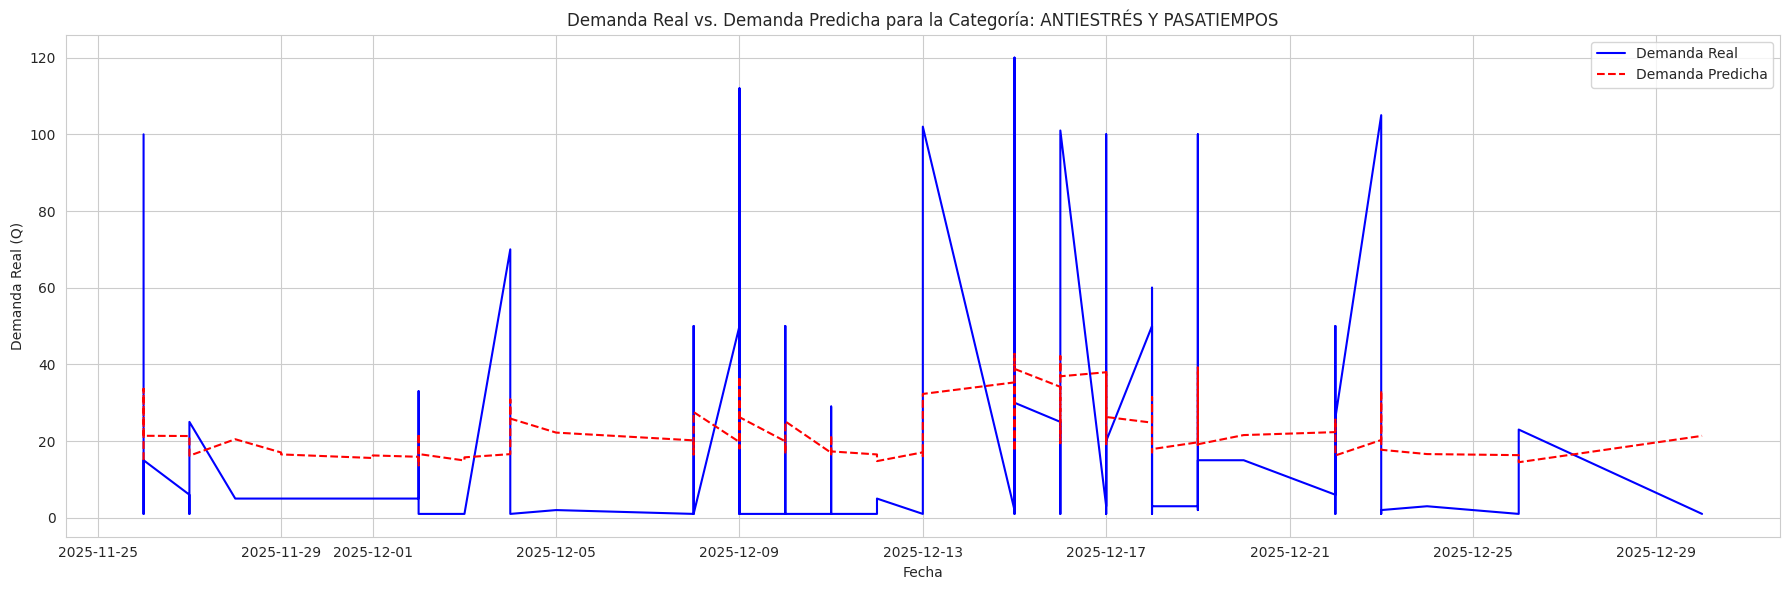

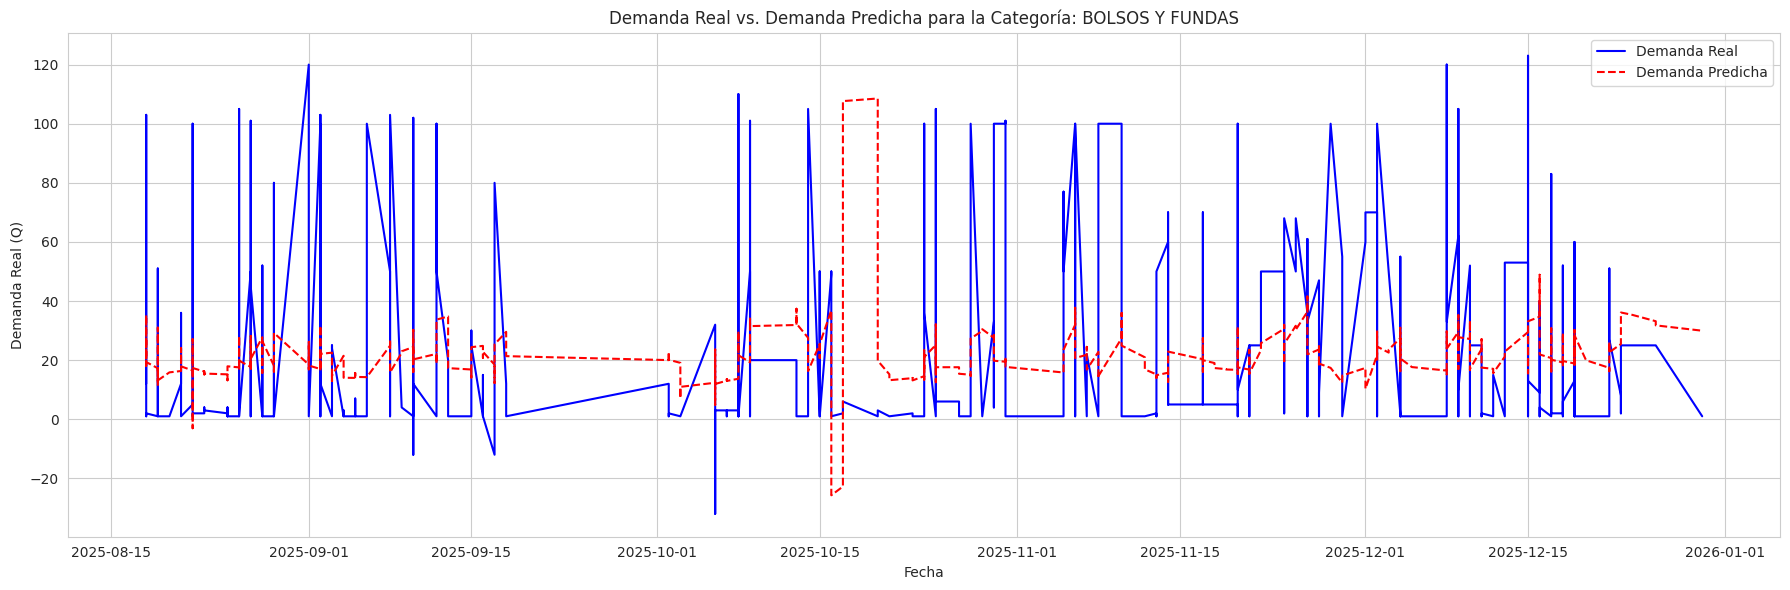

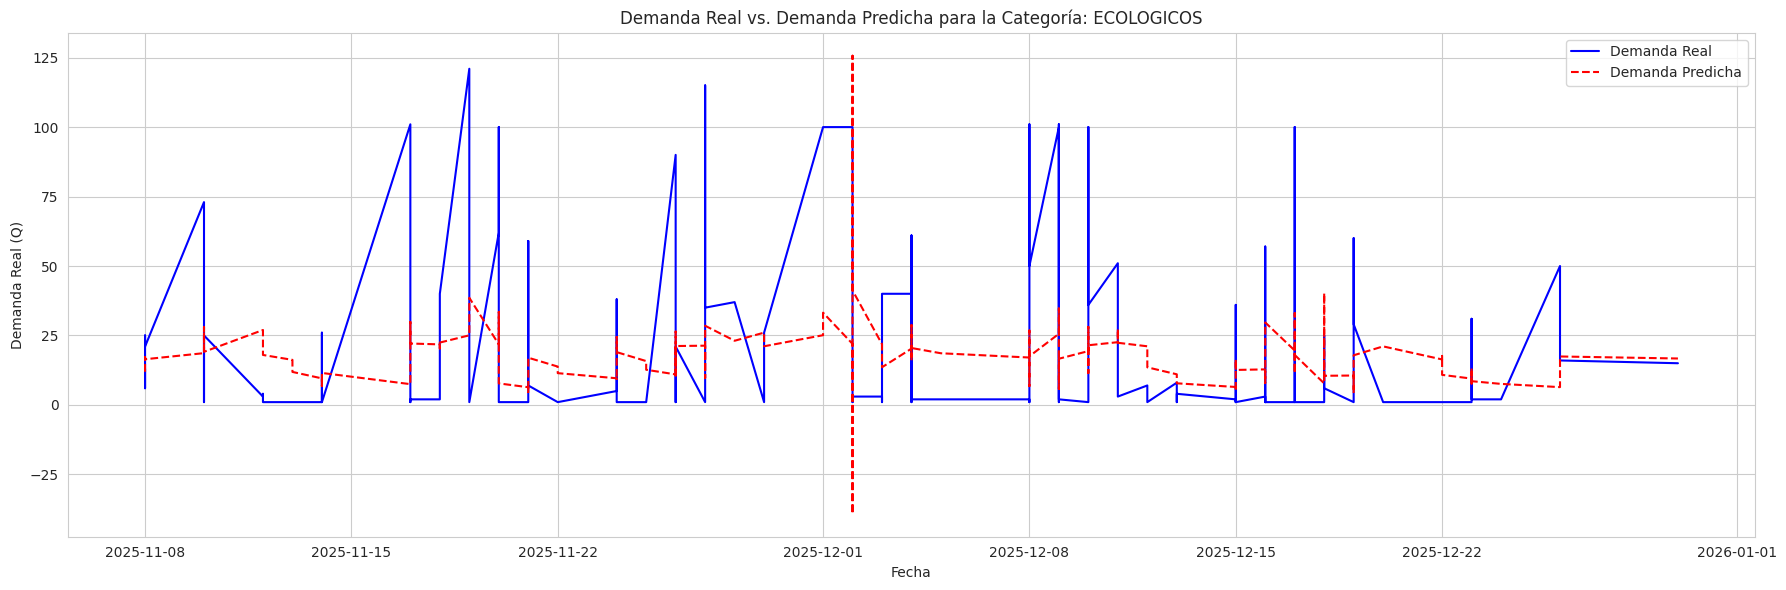

Omitiendo la visualización para la categoría 'ESCOLAR Y OFICINA' como se solicitó.
Omitiendo la visualización para la categoría 'ESCRITURA' como se solicitó.


ValueError: x and y must have same first dimension, but have shapes (1099,) and (1351,)

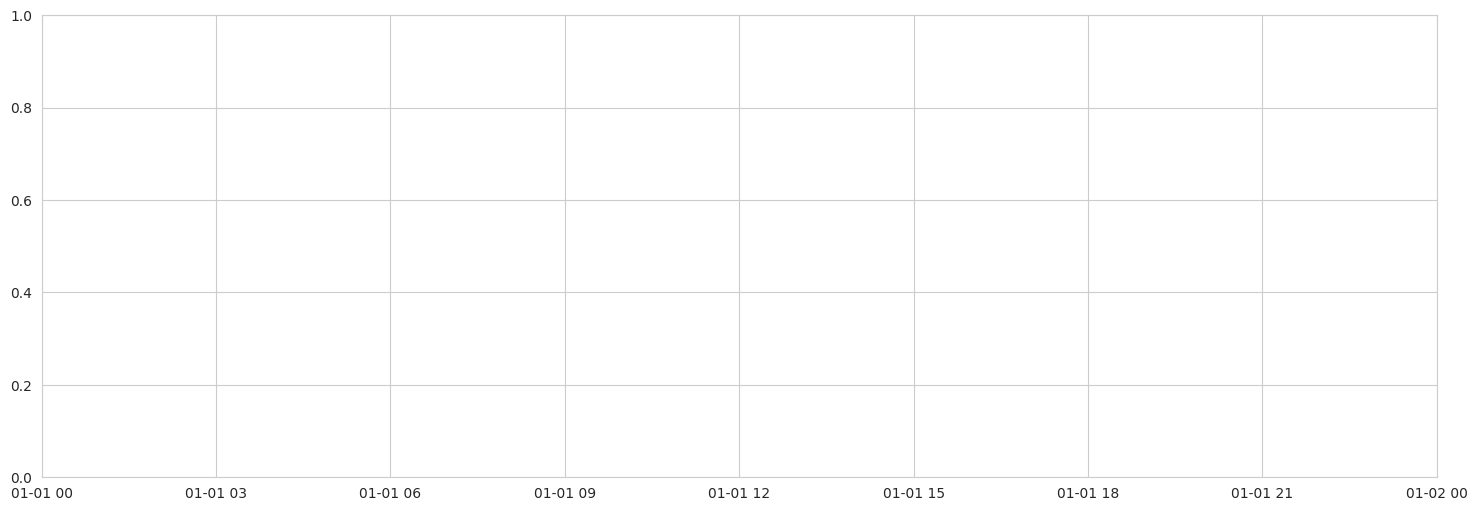

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))

# Categorías a excluir de la visualización debido a datos insuficientes para look_back
categories_to_exclude = ['ESCOLAR Y OFICINA', 'ESCRITURA']

# Generar gráficos para cada categoría
for category, predictions in lstm_predictions.items():
    if category in categories_to_exclude:
        print(f"Omitiendo la visualización para la categoría '{category}' como se solicitó.")
        continue

    y_true = predictions['y_true']
    y_pred = predictions['y_pred']
    test_dates = predictions['test_dates']

    # Asegurarse de que y_true y y_pred tengan la misma longitud que test_dates
    # Puede haber una ligera discrepancia debido al look_back en la creación del dataset LSTM
    start_idx = len(test_dates) - len(y_true)
    if start_idx < 0:
        start_idx = 0
    current_test_dates = test_dates[start_idx : start_idx + len(y_true)]

    if len(current_test_dates) == 0 or len(y_true) == 0 or len(y_pred) == 0:
        print(f"Advertencia: No hay suficientes datos para graficar la categoría {category}. Saltando.")
        continue

    plt.figure(figsize=(18, 6))
    plt.plot(current_test_dates, y_true, label='Demanda Real', color='blue')
    plt.plot(current_test_dates, y_pred, label='Demanda Predicha', color='red', linestyle='--')
    plt.title(f'Demanda Real vs. Demanda Predicha para la Categoría: {category}')
    plt.xlabel('Fecha')
    plt.ylabel('Demanda Real (Q)')
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Visualización de resultados completada para todas las categorías disponibles (excluyendo las omitidas).")

### 9. Reporte de Resultados

A continuación se presenta un informe detallado del proceso de análisis y modelado predictivo, la interpretación de las métricas obtenidas y una tabla resumen de los resultados por categoría.

#### Explicación del Proceso Realizado

El análisis comenzó con la carga del dataset `Ventas 2023-2025`. Durante la fase de **preprocesamiento de datos**, se realizó una exploración inicial para entender la estructura, tipos de datos y presencia de valores nulos. Posteriormente, se aplicó el método del rango intercuartílico (IQR) para **detectar y eliminar valores atípicos** en la columna 'DEMANDA REAL (Q)', lo que ayudó a limpiar los datos de posibles valores extremos que podrían sesgar el modelado. También se realizó una **limpieza y transformación de tipos de datos**, convirtiendo columnas numéricas con formatos de texto (como moneda y porcentaje) a tipos numéricos flotantes y la columna 'FECHA' a formato datetime. Los valores nulos resultantes de estas conversiones fueron tratados rellenándolos con 0 o eliminando las filas correspondientes.

La siguiente fase fue la **segmentación de datos por categoría**. El DataFrame principal se dividió en subconjuntos, uno por cada categoría única presente en la columna 'CATEGORIA'. Este enfoque permitió un análisis y modelado independiente para cada segmento, tal como se solicitó.

Para la **preparación de datos para el modelado LSTM**, los datos de cada categoría fueron ordenados cronológicamente, un paso esencial para series de tiempo. Luego, las variables numéricas, incluyendo la demanda, fueron **normalizadas** a un rango de 0 a 1 utilizando `MinMaxScaler`, lo cual es crucial para la estabilidad y el rendimiento de las redes neuronales. Finalmente, los datos se **dividieron** en conjuntos de entrenamiento (80%) y prueba (20%) de manera secuencial, conservando el orden temporal.

La fase de **modelado con LSTM** implicó la construcción y entrenamiento de un modelo de red neuronal LSTM para cada categoría. Los modelos fueron configurados con una capa LSTM de 50 unidades, activadas por una función 'relu', seguida de una capa densa de una sola neurona para la predicción. Se utilizó el optimizador 'adam' y la función de pérdida 'mean_squared_error'. Los modelos se entrenaron durante 50 épocas con un tamaño de lote de 32 y una ventana de tiempo ('look_back') de 10.

Finalmente, se procedió a la **evaluación del modelo** utilizando diversas métricas para cuantificar el rendimiento de cada modelo en su conjunto de prueba. Las métricas calculadas fueron MSE, RMSE, MAE, MAPE y R².

#### Interpretación de las Métricas por Categoría

Los valores de las métricas obtenidas para cada categoría indican lo siguiente:

*   **MSE y RMSE**: Son medidas de la magnitud de los errores del modelo. Valores más bajos indican un mejor ajuste. Los valores obtenidos, aunque varían, sugieren que los modelos tienen un grado de error absoluto considerable en las unidades originales de la demanda.
*   **MAE**: Representa el promedio de los errores absolutos. Es menos sensible a los outliers que el MSE/RMSE. Similar a las anteriores, valores más bajos son preferibles.
*   **MAPE**: Mide el error porcentual absoluto promedio. Valores de MAPE muy altos (como los observados alrededor del 500% - 900%) son preocupantes e indican que las predicciones tienen un error porcentual muy grande en relación con los valores reales. Esto podría ser problemático especialmente en series de tiempo con valores pequeños o fluctuantes. A menudo, un MAPE alto es resultado de tener muchos valores pequeños en `y_true`, donde incluso un pequeño error absoluto se traduce en un gran error porcentual. También podría indicar que el modelo no está capturando bien la dinámica de la demanda o que las características no son lo suficientemente predictivas.
*   **R²**: El coeficiente de determinación indica la proporción de la varianza en la variable dependiente (demanda real) que es predecible a partir de las variables independientes utilizadas. Valores cercanos a 1 indican un modelo que explica una gran parte de la varianza, mientras que valores cercanos a 0 o negativos (como se observa en 'BOLSOS Y FUNDAS' y 'ECOLOGICOS') sugieren que el modelo no explica la varianza de la demanda, o incluso que se ajusta peor que un modelo que predice la media de los datos. En este caso, los valores de R² son muy bajos o negativos para la mayoría de las categorías, lo que indica que los modelos LSTM actuales no están logrando un buen ajuste a los datos de demanda. Esto podría deberse a la complejidad de la serie, la falta de características predictivas fuertes, o la necesidad de optimización del modelo (arquitectura, hiperparámetros, más datos, etc.).

En resumen, las métricas actuales sugieren que los modelos LSTM, en su configuración actual, no están proporcionando predicciones de demanda muy precisas para la mayoría de las categorías. Un MAPE tan elevado y un R² tan bajo o negativo son indicadores claros de que se requiere una optimización significativa, una reevaluación de las características de entrada, o una posible reconsideración de la idoneidad del modelo LSTM para estas series de tiempo particulares.

In [16]:
print("\n#### Tabla Resumen de Métricas de Evaluación por Categoría:\n")
display(metrics_df.set_index('Categoría').round(2))


#### Tabla Resumen de Métricas de Evaluación por Categoría:



,MSE,RMSE,MAE,MAPE,R2
Categoría,,,,,
ANTIESTRÉS Y PASATIEMPOS,1050.68,32.41,24.53,829.36,0.05
BOLSOS Y FUNDAS,943.61,30.72,23.37,886.57,-0.06
ECOLOGICOS,908.22,30.14,21.71,868.34,-0.12
ESCOLAR Y OFICINA,538.24,23.20,14.09,451.76,0.05
ESCRITURA,1471.87,38.36,30.85,978.78,0.03
JARROS,796.50,28.22,21.94,776.03,0.02
LLAVEROS,772.27,27.79,18.99,571.21,0.01
TOMATODOS,504.95,22.47,15.59,597.39,0.03


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Función para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    # Para evitar división por cero, se puede añadir una pequeña constante o manejar de otra forma
    # Aquí se maneja como NaN si y_true es 0
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results_metrics = []

for category, predictions in lstm_predictions.items():
    y_true = predictions['y_true']
    y_pred = predictions['y_pred']

    if len(y_true) == 0 or len(y_pred) == 0:
        print(f"Advertencia: No hay suficientes datos para evaluar la categoría {category}. Saltando.")
        continue

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    # Manejar el MAPE para evitar divisiones por cero o valores muy pequeños
    # Reemplazar valores de y_true iguales a cero con un valor muy pequeño (epsilon)
    # para evitar errores de división por cero, o simplemente no calcular si es el caso.
    y_true_mape = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_mape)) * 100

    r2 = r2_score(y_true, y_pred)

    results_metrics.append({
        'Categoría': category,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    })
    print(f"\nMétricas para la categoría: {category}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R2: {r2:.4f}")

metrics_df = pd.DataFrame(results_metrics)
print("\nResumen de métricas para todas las categorías:")
display(metrics_df)



Métricas para la categoría: ANTIESTRÉS Y PASATIEMPOS
  MSE: 1050.6798
  RMSE: 32.4142
  MAE: 24.5277
  MAPE: 829.36%
  R2: 0.0528

Métricas para la categoría: BOLSOS Y FUNDAS
  MSE: 943.6147
  RMSE: 30.7183
  MAE: 23.3735
  MAPE: 886.57%
  R2: -0.0629

Métricas para la categoría: ECOLOGICOS
  MSE: 908.2179
  RMSE: 30.1367
  MAE: 21.7070
  MAPE: 868.34%
  R2: -0.1227

Métricas para la categoría: ESCOLAR Y OFICINA
  MSE: 538.2352
  RMSE: 23.1999
  MAE: 14.0929
  MAPE: 451.76%
  R2: 0.0523

Métricas para la categoría: ESCRITURA
  MSE: 1471.8675
  RMSE: 38.3649
  MAE: 30.8530
  MAPE: 978.78%
  R2: 0.0260

Métricas para la categoría: JARROS
  MSE: 796.5037
  RMSE: 28.2224
  MAE: 21.9429
  MAPE: 776.03%
  R2: 0.0191

Métricas para la categoría: LLAVEROS
  MSE: 772.2681
  RMSE: 27.7897
  MAE: 18.9865
  MAPE: 571.21%
  R2: 0.0094

Métricas para la categoría: TOMATODOS
  MSE: 504.9457
  RMSE: 22.4710
  MAE: 15.5905
  MAPE: 597.39%
  R2: 0.0274

Resumen de métricas para todas las categorías:


,Categoría,MSE,RMSE,MAE,MAPE,R2
0,ANTIESTRÉS Y PASATIEMPOS,1050.679848,32.414192,24.527708,829.363270,0.052772
1,BOLSOS Y FUNDAS,943.614745,30.718313,23.373455,886.572980,-0.062920
2,ECOLOGICOS,908.217900,30.136654,21.706952,868.341187,-0.122726
3,ESCOLAR Y OFICINA,538.235243,23.199897,14.092941,451.756013,0.052307
4,ESCRITURA,1471.867532,38.364926,30.853020,978.784134,0.025972
5,JARROS,796.503730,28.222398,21.942897,776.026081,0.019107
6,LLAVEROS,772.268067,27.789712,18.986525,571.207301,0.009435
7,TOMATODOS,504.945694,22.470997,15.590544,597.391453,0.027385


In [9]:
# Asegurarse de que la columna 'CATEGORIA' exista
if 'CATEGORIA' in df.columns:
    unique_categories = df['CATEGORIA'].unique()
    print(f"Categorías únicas encontradas: {len(unique_categories)}")
    print("\nLista de Categorías:")
    for category in unique_categories:
        print(f"- {category}")

    # Crear un diccionario para almacenar los DataFrames segmentados por categoría
    df_by_category = {}
    for category in unique_categories:
        df_by_category[category] = df[df['CATEGORIA'] == category].copy()
        print(f"\nDataFrame para la categoría '{category}': {df_by_category[category].shape[0]} filas")
        # Opcional: mostrar las primeras filas de cada sub-DataFrame
        # display(df_by_category[category].head())
else:
    print("La columna 'CATEGORIA' no se encontró en el DataFrame. No se realizó la segmentación.")


Categorías únicas encontradas: 8

Lista de Categorías:
- ANTIESTRÉS Y PASATIEMPOS
- BOLSOS Y FUNDAS
- ECOLOGICOS
- ESCOLAR Y OFICINA
- ESCRITURA
- JARROS
- LLAVEROS
- TOMATODOS

DataFrame para la categoría 'ANTIESTRÉS Y PASATIEMPOS': 966 filas

DataFrame para la categoría 'BOLSOS Y FUNDAS': 3242 filas

DataFrame para la categoría 'ECOLOGICOS': 1291 filas

DataFrame para la categoría 'ESCOLAR Y OFICINA': 12831 filas

DataFrame para la categoría 'ESCRITURA': 24429 filas

DataFrame para la categoría 'JARROS': 6805 filas

DataFrame para la categoría 'LLAVEROS': 3475 filas

DataFrame para la categoría 'TOMATODOS': 6553 filas


### 2. Detección y Eliminación de Outliers (Valores Atípicos) usando IQR

Para garantizar la integridad de los datos y evitar que los valores extremos sesguen nuestro modelo, detectaremos y eliminaremos los outliers. Utilizaremos el método del rango intercuartílico (IQR) en la columna 'DEMANDA', ya que es la variable objetivo para la predicción.

In [6]:
# Identificar y manejar valores nulos en la columna 'DEMANDA' antes de la detección de outliers
# Por simplicidad, rellenaremos los nulos con la mediana para no perder filas,
# pero otras estrategias podrían ser más adecuadas dependiendo del contexto.
if 'DEMANDA REAL (Q)' in df.columns:
    initial_rows = df.shape[0]
    # Convertir a numérico, manejando errores
    df['DEMANDA REAL (Q)'] = pd.to_numeric(df['DEMANDA REAL (Q)'], errors='coerce')
    df['DEMANDA REAL (Q)'].fillna(df['DEMANDA REAL (Q)'].median(), inplace=True)
    print(f"Se rellenaron los valores nulos en 'DEMANDA REAL (Q)' con la mediana. Filas iniciales: {initial_rows}")

    # Calcular Q1 (cuartil 25) y Q3 (cuartil 75) para la columna 'DEMANDA REAL (Q)'
    Q1 = df['DEMANDA REAL (Q)'].quantile(0.25)
    Q3 = df['DEMANDA REAL (Q)'].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites para la detección de outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = df[(df['DEMANDA REAL (Q)'] < lower_bound) | (df['DEMANDA REAL (Q)'] > upper_bound)]
    print(f"\nNúmero de outliers detectados en 'DEMANDA REAL (Q)': {len(outliers)}")
    if not outliers.empty:
        print("\nEjemplo de outliers (primeras 5 filas):")
        display(outliers.head())

    # Eliminar outliers del DataFrame original
    df_cleaned = df[~((df['DEMANDA REAL (Q)'] < lower_bound) | (df['DEMANDA REAL (Q)'] > upper_bound))].copy()
    print(f"\nDataFrame original: {df.shape[0]} filas")
    print(f"DataFrame después de eliminar outliers: {df_cleaned.shape[0]} filas")
    print(f"Se eliminaron {df.shape[0] - df_cleaned.shape[0]} filas debido a outliers.")

    # Actualizar el DataFrame a la versión limpia
    df = df_cleaned
else:
    print("La columna 'DEMANDA REAL (Q)' no se encontró en el DataFrame. No se realizó la detección de outliers.")

Se rellenaron los valores nulos en 'DEMANDA REAL (Q)' con la mediana. Filas iniciales: 68034

Número de outliers detectados en 'DEMANDA REAL (Q)': 8442

Ejemplo de outliers (primeras 5 filas):


/tmp/ipykernel_429/1125658857.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DEMANDA REAL (Q)'].fillna(df['DEMANDA REAL (Q)'].median(), inplace=True)


,FECHA,AÑO,MES,CLIENTES,CODIGO PRODUCTO,CATEGORIA,SUBCATEGORIA,DEMANDA REAL (Q),PRECIO TOTAL,DESCUENTO,DSC %,SUBTOTAL PRODUCTO ANTES DE IMPUESTOS,IVA TOTAL,IVA %,TOTAL PRODUCTO,COSTO TOTAL,GRUPO CLIENTES,TARIFA FACTURA
6,6/4/2023,2023,ABRIL,CL0097,PR0678,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,2711,"$1.161,86",$-,0%,"$1.161,86","$139,42",12%,"$1.301,28","$731,97",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
7,10/4/2023,2023,ABRIL,CL0128,PR1120,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,299,"$140,95",$-,0%,"$140,95","$16,91",12%,"$157,86","$71,76",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
18,13/4/2023,2023,ABRIL,CL0099,PR1113,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,2500,"$1.178,50",$-,0%,"$1.178,50","$141,42",12%,"$1.319,92","$600,00",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
20,13/4/2023,2023,ABRIL,CL0246,PR0677,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,201,"$107,68",$-,0%,"$107,68","$12,92",12%,"$120,60","$54,27",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
24,17/4/2023,2023,ABRIL,CL0293,PR0470,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,252,"$135,00",$-,0%,"$135,00","$16,20",12%,"$151,20","$68,04",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR



DataFrame original: 68034 filas
DataFrame después de eliminar outliers: 59592 filas
Se eliminaron 8442 filas debido a outliers.
